In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from dataclasses import dataclass
from lunanav.constants import GM_MOON, R_MOON, RAD_TO_DEG, MOON_3_VEC
from lunanav.sim.simulator import SimParams, RigidBody, run_sim, SimResults, reverse_sim_results
from lunanav.sim.sensors import (
    SensorEnvironment, Sensor, SensorSuite, SensorName,
    accelerometer_sensor, gyroscope_sensor,
    laser_altimeter_sensor, laser_velocity_sensor,
    star_tracker_sensor, doppler_sensor, sat_range_tracker_sensor
)
import plotly.graph_objects as go
from lunanav.estimation.ekf import ekf_predict, ekf_update, Qd_from_accel_white, update_sensor_individual_NaN_check
from lunanav.sim.quaternion import unitize_state, angle_axis_to_q, quat_apply, conj
from lunanav.plotting import plot_control_effort, plot_state_vector_combined, plot_state_vector_combined_log, plot_state_vector
from lunanav.visualization import visualize_trajectory, plot_measurements, plot_attitude_relative_vertical, plot_filter_confidence, obsv_verbose, plot_sensor_config_comparison
from lunanav.sim.sensors import get_los_vectors
from lunanav.loaders import load_trajectory, load_sim_result, load_ekf_result
from lunanav.sim.generate import SatPosVel, make_sat_arrs, generate_env

In [4]:

sim_result = load_sim_result("data/simresults/ilqr_better.json")

# s_true   = sim_result.s_true
# t        = sim_result.t_arr
dt       = sim_result.dt
n        = sim_result.nsteps
# mass_kg  = sim_result.mass_kg
# I        = sim_result.I.reshape((3, 3))

results = SimResults(n)

results.t = sim_result.t
results.states = sim_result.s_arr
results.force_N = sim_result.force
results.torque_Nm = sim_result.torque

lander = RigidBody(
    mass_kg=sim_result.mass_kg,
    I=sim_result.I
)

measurements_clean = {
    SensorName(k): np.array(v["truth"]) for k, v in sim_result.measurements.items()
}
measurements_noisy = {
    SensorName(k): np.array(v["noisy"]) for k, v in sim_result.measurements.items()
}
print(f"Loaded sim result: {n} steps, dt={dt}s")

Loaded sim result: 2000 steps, dt=0.1s


In [5]:


# Noise parameters (match main notebook)
sigma_accel = 1
sigma_gyro = 1e-3
sigma_los = 1
sigma_los_vel = 1
sigma_star = 1e-3
sigma_doppler = 0.1
sigma_sat_range_tracker = 10

state0 = results.states[0]
sim = SimParams(state0, lander, dt, results.t[-1])

sensor_suite = SensorSuite(sensors={
    SensorName.ACCELEROMETER: accelerometer_sensor(sigma_accel),
    SensorName.GYROSCOPE: gyroscope_sensor(sigma_gyro),
    SensorName.LASER_ALTIMETER: laser_altimeter_sensor(sigma_los),
    SensorName.LASER_VELOCITY: laser_velocity_sensor(sigma_los_vel),
    SensorName.STAR_TRACKER: star_tracker_sensor(sigma_star),
    SensorName.DOPPLER: doppler_sensor(3, sigma_doppler),
    SensorName.RANGE_TRACKER: sat_range_tracker_sensor(3, sigma_sat_range_tracker),
})

doppler_sats = [
    make_sat_arrs(results.t, altitude=100e3, raan=0, aop=90, inc=90),
    make_sat_arrs(results.t, altitude=100e3, raan=90, aop=94, inc=94),
    make_sat_arrs(results.t, altitude=100e3, raan=160, aop=70, inc=86),
]

env_arr = generate_env(results, sim, doppler_sats)
print("Sensor suite and environment ready")

Sensor suite and environment ready


In [6]:
from lunanav.estimation.ekf import ekf_predict, update_sensor, Qd_from_accel_white
from lunanav.sim.quaternion import unitize_state

# Q matrix
Q6 = Qd_from_accel_white(dt, sigma_accel)
Q_att = np.eye(4) * (sigma_gyro * dt)**2
Q_ang = np.eye(3) * (sigma_gyro * dt)**2
Q_ekf = np.block([
    [Q6,                   np.zeros((6, 4)), np.zeros((6, 3))],
    [np.zeros((4, 6)), Q_att,              np.zeros((4, 3))],
    [np.zeros((3, 6)), np.zeros((3, 4)), Q_ang],
])
print("EKF Q matrix ready")

EKF Q matrix ready


# Sensor Ablation Study

Run EKF with different sensor subsets to evaluate observability.

In [7]:
# Define sensor dropout configurations with meaningful combinations
sensor_configs = [
    {
        "name": "All Sensors",
        "description": "All sensors active (baseline)",
        "frequencies": {
            SensorName.LASER_ALTIMETER: 1,
            SensorName.LASER_VELOCITY: 1,
            SensorName.STAR_TRACKER: 1,
            SensorName.DOPPLER: 1,
            SensorName.RANGE_TRACKER: 1,
        }
    },
    {
        "name": "No Altimeter",
        "description": "Height-blind configuration (no laser altitude)",
        "frequencies": {
            SensorName.LASER_ALTIMETER: None,
            SensorName.LASER_VELOCITY: 1,
            SensorName.STAR_TRACKER: 1,
            SensorName.DOPPLER: 1,
            SensorName.RANGE_TRACKER: 1,
        }
    },
    {
        "name": "No Laser Velocity",
        "description": "Without local velocity measurement",
        "frequencies": {
            SensorName.LASER_ALTIMETER: 1,
            SensorName.LASER_VELOCITY: None,
            SensorName.STAR_TRACKER: 1,
            SensorName.DOPPLER: 1,
            SensorName.RANGE_TRACKER: 1,
        }
    },
    {
        "name": "No Star Tracker",
        "description": "No absolute attitude reference",
        "frequencies": {
            SensorName.LASER_ALTIMETER: 1,
            SensorName.LASER_VELOCITY: 1,
            SensorName.STAR_TRACKER: None,
            SensorName.DOPPLER: 1,
            SensorName.RANGE_TRACKER: 1,
        }
    },
    {
        "name": "Laser Only",
        "description": "Terrain-relative navigation (ideal TRN)",
        "frequencies": {
            SensorName.LASER_ALTIMETER: 1,
            SensorName.LASER_VELOCITY: 1,
            SensorName.STAR_TRACKER: None,
            SensorName.DOPPLER: None,
            SensorName.RANGE_TRACKER: None,
        }
    },
    {
        "name": "Laser + Star Tracker",
        "description": "TRN with attitude reference",
        "frequencies": {
            SensorName.LASER_ALTIMETER: 1,
            SensorName.LASER_VELOCITY: 1,
            SensorName.STAR_TRACKER: 1,
            SensorName.DOPPLER: None,
            SensorName.RANGE_TRACKER: None,
        }
    },
    {
        "name": "Vision + Navigation",
        "description": "Star tracker + Doppler + Range (no local sensors)",
        "frequencies": {
            SensorName.LASER_ALTIMETER: None,
            SensorName.LASER_VELOCITY: None,
            SensorName.STAR_TRACKER: 1,
            SensorName.DOPPLER: 1,
            SensorName.RANGE_TRACKER: 1,
        }
    },
    {
        "name": "IMU Only",
        "description": "Dead reckoning (accelerometer + gyro only)",
        "frequencies": {
            SensorName.LASER_ALTIMETER: None,
            SensorName.LASER_VELOCITY: None,
            SensorName.STAR_TRACKER: None,
            SensorName.DOPPLER: None,
            SensorName.RANGE_TRACKER: None,
        }
    },
]

sensor_frequencies = {
    SensorName.LASER_ALTIMETER: 1,
    SensorName.LASER_VELOCITY: 1,
    SensorName.STAR_TRACKER: 1,
    SensorName.DOPPLER: 1,
    SensorName.RANGE_TRACKER: 1,
}

In [8]:
results.states[0]

array([ 0.00000000e+00,  8.02593438e+04,  1.76892088e+06, -0.00000000e+00,
       -1.65415979e+03, -2.30084839e+02,  7.99828887e-01, -6.00228071e-01,
        0.00000000e+00,  0.00000000e+00, -3.64465304e-02, -0.00000000e+00,
       -0.00000000e+00])

In [23]:
# Run EKF for each configuration (no initial offset)
no_offset_results_list = []

for config in sensor_configs:
    print(f"\n{'='*60}")
    print(f"Running: {config['name']}")
    print(f"Description: {config['description']}")
    print(f"{'='*60}")
    
    mu_arr = np.zeros((n, 13)) * np.nan
    Sigma_arr = np.zeros((n, 13, 13)) * np.nan
    
    mu_arr[0] = results.states[0]
    Sigma_arr[0] = np.eye(13)
    
    valid = True
    for i in tqdm(range(n - 1)):
        accel_meas = sim_result.measurements[SensorName.ACCELEROMETER.value]['truth'][i] 
        gyro_meas = results.states[i, 10:13]
        
        mu_pred, Sigma_pred = ekf_predict(mu_arr[i], Sigma_arr[i], accel_meas, gyro_meas, Q_ekf, sim)
        mu_pred = unitize_state(mu_pred)

        if jnp.any(jnp.isnan(mu_pred)):
            print(f"NaN after predict at i={i}")
            break
        
        env = env_arr[i]


        # for sensor, freq in config['frequencies'].items():
        #     mu_pred, Sigma_pred = update_sensor(sensor, freq, mu_pred, Sigma_pred, env, sensor_suite, measurements_noisy, i)
        
        for sensor, use in config['frequencies'].items():
            if use in [0, None]:
                continue
            
            freq = sensor_frequencies[sensor]
            if sensor in [SensorName.LASER_ALTIMETER, SensorName.LASER_VELOCITY]:
                mu_pred, Sigma_pred = update_sensor_individual_NaN_check(sensor, freq, mu_pred, Sigma_pred, env, sensor_suite, measurements_noisy, i)
            else:
                mu_pred, Sigma_pred = update_sensor(sensor, freq, mu_pred, Sigma_pred, env, sensor_suite, measurements_noisy, i)

            if jnp.any(jnp.isnan(mu_pred)):
                print(f"NaN after update for {sensor} at i={i}")
                valid = False
        mu_arr[i + 1] = mu_pred
        Sigma_arr[i + 1] = Sigma_pred

        if not valid:
            break
    
    pos_error = np.linalg.norm(mu_arr[:, 0:3] - results.states[:, 0:3], axis=1)
    vel_error = np.linalg.norm(mu_arr[:, 3:6] - results.states[:, 3:6], axis=1)
    att_error = np.linalg.norm(mu_arr[:, 6:10] - results.states[:, 6:10], axis=1)
    
    no_offset_results_list.append({
        "name": config['name'],
        "description": config['description'],
        "config": config['frequencies'],
        "mu_arr": mu_arr,
        "Sigma_arr": Sigma_arr,
        "pos_error": pos_error,
        "vel_error": vel_error,
        "att_error": att_error,
    })

print("\n" + "="*60)
print("All configurations completed!")
print("="*60)


Running: All Sensors
Description: All sensors active (baseline)


100%|██████████| 1999/1999 [00:49<00:00, 40.57it/s]



Running: No Altimeter
Description: Height-blind configuration (no laser altitude)


100%|██████████| 1999/1999 [00:39<00:00, 50.89it/s]



Running: No Laser Velocity
Description: Without local velocity measurement


...


Running: Vision + Navigation
Description: Star tracker + Doppler + Range (no local sensors)


100%|██████████| 1999/1999 [00:31<00:00, 63.06it/s]



Running: IMU Only
Description: Dead reckoning (accelerometer + gyro only)


100%|██████████| 1999/1999 [00:02<00:00, 715.78it/s]


All configurations completed!


In [10]:
# Run EKF for each configuration (no initial offset)
offset_results_list = []

for config in sensor_configs:
    print(f"\n{'='*60}")
    print(f"Running: {config['name']}")
    print(f"Description: {config['description']}")
    print(f"{'='*60}")
    
    mu_arr = np.ones((n, 13)) * np.nan
    Sigma_arr = np.ones((n, 13, 13)) * np.nan
    
    mu_arr[0] = results.states[0] + np.array([1e3, -1e3, 1e3, 1e2, 1e2, 1e2, *angle_axis_to_q(90, [0,1,0], True), 10 * RAD_TO_DEG, -14 * RAD_TO_DEG, 30 * RAD_TO_DEG])
    mu_arr[0] = unitize_state(mu_arr[0])
    Sigma_arr[0] = np.eye(13)
    valid = True
    for i in tqdm(range(n - 1)):
        accel_meas = sim_result.measurements[SensorName.ACCELEROMETER.value]['truth'][i] 
        gyro_meas = results.states[i, 10:13]
        
        mu_pred, Sigma_pred = ekf_predict(mu_arr[i], Sigma_arr[i], accel_meas, gyro_meas, Q_ekf, sim)
        mu_pred = unitize_state(mu_pred)

        if jnp.any(jnp.isnan(mu_pred)):
            print(f"NaN after predict at i={i}")
            break
        
        env = env_arr[i]

        for sensor, use in config['frequencies'].items():
            if use in [0, None]:
                continue
            
            freq = sensor_frequencies[sensor]
            if sensor in [SensorName.LASER_ALTIMETER, SensorName.LASER_VELOCITY]:
                mu_pred, Sigma_pred = update_sensor_individual_NaN_check(sensor, freq, mu_pred, Sigma_pred, env, sensor_suite, measurements_noisy, i)
            else:
                mu_pred, Sigma_pred = update_sensor(sensor, freq, mu_pred, Sigma_pred, env, sensor_suite, measurements_noisy, i)

            if jnp.any(jnp.isnan(mu_pred)):
                print(f"NaN after update for {sensor} at i={i}")
                valid = False
        mu_arr[i + 1] = mu_pred
        Sigma_arr[i + 1] = Sigma_pred

        if not valid:
            break
    
    pos_error = np.linalg.norm(mu_arr[:, 0:3] - results.states[:, 0:3], axis=1)
    vel_error = np.linalg.norm(mu_arr[:, 3:6] - results.states[:, 3:6], axis=1)
    att_error = np.linalg.norm(mu_arr[:, 6:10] - results.states[:, 6:10], axis=1)
    
    offset_results_list.append({
        "name": config['name'],
        "description": config['description'],
        "config": config['frequencies'],
        "mu_arr": mu_arr,
        "Sigma_arr": Sigma_arr,
        "pos_error": pos_error,
        "vel_error": vel_error,
        "att_error": att_error,
    })

print("\n" + "="*60)
print("All configurations completed!")
print("="*60)


Running: All Sensors
Description: All sensors active (baseline)


100%|██████████| 1999/1999 [00:42<00:00, 47.04it/s]



Running: No Altimeter
Description: Height-blind configuration (no laser altitude)


100%|██████████| 1999/1999 [00:45<00:00, 44.27it/s]



Running: No Laser Velocity
Description: Without local velocity measurement


...


Running: Vision + Navigation
Description: Star tracker + Doppler + Range (no local sensors)


100%|██████████| 1999/1999 [00:30<00:00, 65.97it/s]



Running: IMU Only
Description: Dead reckoning (accelerometer + gyro only)


100%|██████████| 1999/1999 [00:03<00:00, 651.18it/s]


All configurations completed!


In [18]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=results.t, y=measurements_noisy[SensorName.LASER_ALTIMETER][:,0], mode='lines', name='LOS1'))
fig.add_trace(go.Scatter(x=results.t, y=measurements_noisy[SensorName.LASER_ALTIMETER][:,1], mode='lines', name='LOS2'))
fig.add_trace(go.Scatter(x=results.t, y=measurements_noisy[SensorName.LASER_ALTIMETER][:,2], mode='lines', name='LOS3'))
fig.add_trace(go.Scatter(x=results.t, y=measurements_noisy[SensorName.LASER_ALTIMETER][:,3], mode='lines', name='LOS4'))
fig.show()

dropout_times = [7.8]
undropout_times = [35.0, 73.1]

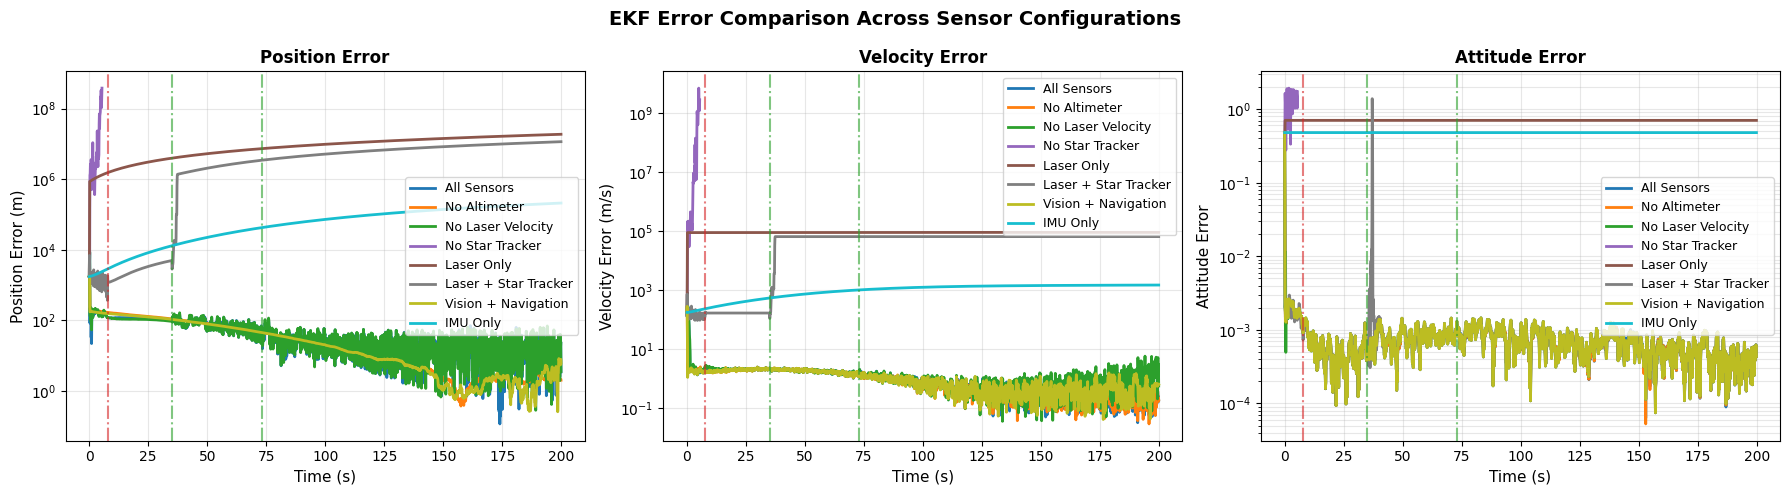


SENSOR CONFIGURATION COMPARISON - FINAL ERROR METRICS

All Sensors               | All sensors active (baseline)
  Position - Final:     3.45 m  | Mean(last):    17.25 m
  Velocity - Final:   0.1856 m/s | Mean(last):   0.2230 m/s
  Attitude - Final:   0.0004

No Altimeter              | Height-blind configuration (no laser altitude)
  Position - Final:     2.01 m  | Mean(last):     2.27 m
  Velocity - Final:   0.1923 m/s | Mean(last):   0.2164 m/s
  Attitude - Final:   0.0004

No Laser Velocity         | Without local velocity measurement
  Position - Final:     3.54 m  | Mean(last):    18.88 m
  Velocity - Final:   0.5572 m/s | Mean(last):   1.7014 m/s
  Attitude - Final:   0.0004

No Star Tracker           | No absolute attitude reference
  Position - Final:      nan m  | Mean(last):      nan m
  Velocity - Final:      nan m/s | Mean(last):      nan m/s
  Attitude - Final:      nan

Laser Only                | Terrain-relative navigation (ideal TRN)
  Position - Final: 18747720.32 m

In [20]:
plot_sensor_config_comparison(offset_results_list, results.t, dropout_times, undropout_times)


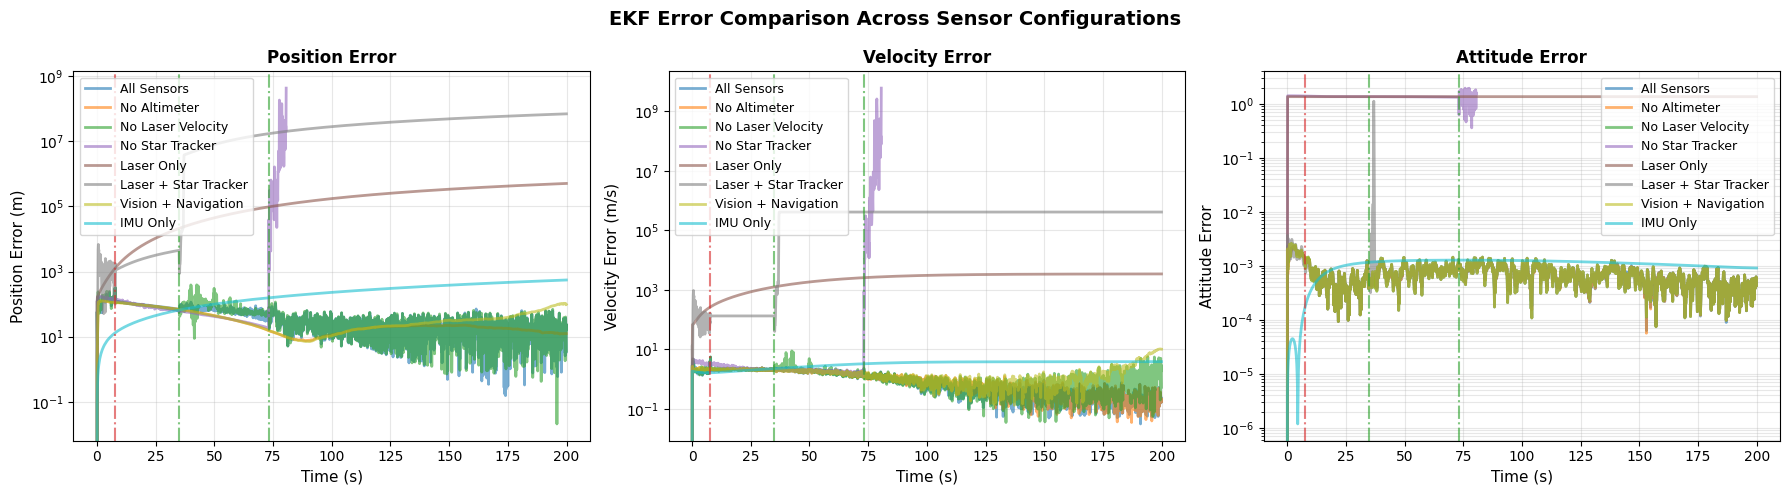


SENSOR CONFIGURATION COMPARISON - FINAL ERROR METRICS

All Sensors               | All sensors active (baseline)
  Position - Final:     3.42 m  | Mean(last):    17.25 m
  Velocity - Final:   0.1856 m/s | Mean(last):   0.2230 m/s
  Attitude - Final:   0.0004

No Altimeter              | Height-blind configuration (no laser altitude)
  Position - Final:    12.40 m  | Mean(last):    12.90 m
  Velocity - Final:   0.1756 m/s | Mean(last):   0.2202 m/s
  Attitude - Final:   0.0004

No Laser Velocity         | Without local velocity measurement
  Position - Final:     3.60 m  | Mean(last):    18.87 m
  Velocity - Final:   0.5371 m/s | Mean(last):   1.7013 m/s
  Attitude - Final:   0.0004

No Star Tracker           | No absolute attitude reference
  Position - Final:      nan m  | Mean(last):      nan m
  Velocity - Final:      nan m/s | Mean(last):      nan m/s
  Attitude - Final:      nan

Laser Only                | Terrain-relative navigation (ideal TRN)
  Position - Final: 507001.72 m  

In [26]:
plot_sensor_config_comparison(no_offset_results_list, results.t, dropout_times, undropout_times)

# Then plot for NO nan